In [61]:
from src.scenario.scenario_writer import ScenarioWriter
from src.scenario.scenario_loader import ScenarioLoader
from src.model.model_builder import Modflow6Builder
from src.data.collector import Collector
from src.data.basemap import BaseMap
from src.utils import drop_duplicates

import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


(1, 300, 500)


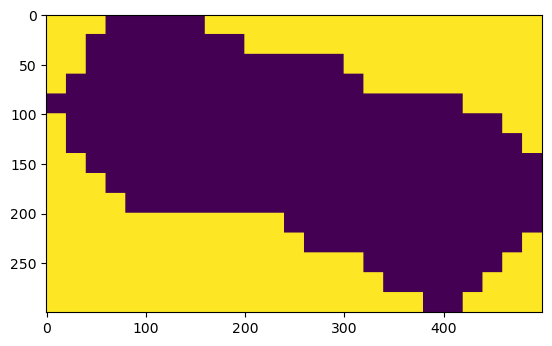

In [62]:
tiffile = rasterio.open("data/base/head.tif")
data = tiffile.read()
print(data.shape)
ddd = data[0]
ddd[ddd==100]= 1000
ddd[ddd==80] = 0

plt.imshow(ddd)
plt.show()


In [ ]:
tiffile = rasterio.open("scenarios/base/idomain.tif")
data = tiffile.read()

df = pd.read_excel("scenarios/base/chd.xls")
chs = []
for i in range(len(df)):
    row,col = basemap.get_index_by_xy(df['x'].tolist()[i], df['y'].tolist()[i])
    if basemap.in_range(col,row):
        chs.append([0, int(row), int(col),df['value'].tolist()[i]])
    if data[0, int(row), int(col)] == 0:
        print(f"警告：位于 ({row}, {col}) 的定水头网格被错误地设置为了 idomain=0！")
plt.imshow(data[0])
plt.show()

NameError: name 'idomain' is not defined

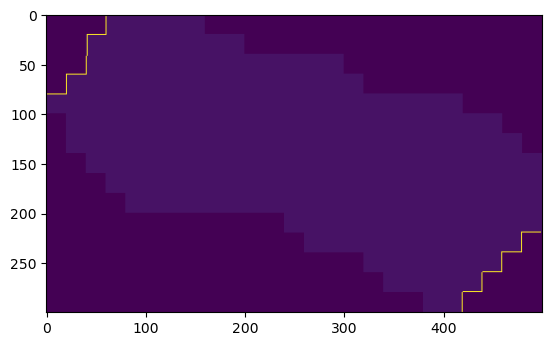

In [ ]:
basemap = BaseMap("scenarios/base/ksep.tif")
df = pd.read_excel("scenarios/base/chd.xls")
chs = []
for i in range(len(df)):
    row,col = basemap.get_index_by_xy(df['x'].tolist()[i], df['y'].tolist()[i])
    if basemap.in_range(col,row):
        chs.append([0, int(row), int(col),df['value'].tolist()[i]])
chs = drop_duplicates(chs, lambda x, y: x[1] == y[1] and x[2] == y[2] and x[0] == y[0])
datan = np.zeros_like(data)
for i in chs:

    datan[i[0],i[1],i[2]] = 20

res = datan[0] + data[0]
np.unique(res)

plt.imshow(datan[0] + data[0])
plt.show()


In [ ]:
pdf = pd.read_excel("scenarios/base/ps.xls")
for i in range(len(pdf)):
    row,col = basemap.get_index_by_xy(pdf['x'].tolist()[i], pdf['y'].tolist()[i])
    print(row, col)

70 70
70 130


In [ ]:

res[70, 70] += 20

res[70, 130] += 20


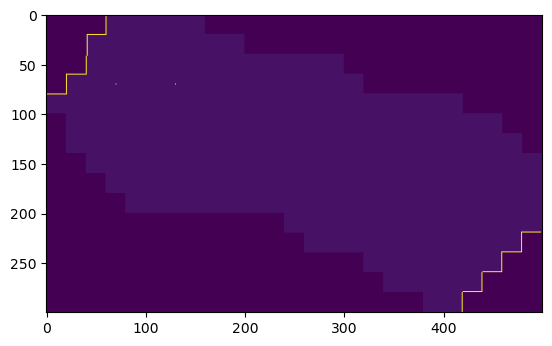

In [ ]:
plt.imshow(res)
plt.show()
